In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

In [3]:
IMG_SIZE = 128
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/palm-recognition/Dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    "/content/drive/MyDrive/palm-recognition/Dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 160 images belonging to 5 classes.
Found 40 images belonging to 5 classes.


In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(train_data.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [7]:

checkpoint = ModelCheckpoint(
    "best_palm_model.h5",        # file name
    monitor='val_accuracy',      # metric to track
    save_best_only=True,         # save only best model
    mode='max',                  # maximize accuracy
    verbose=1
)

In [8]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[checkpoint]
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1523 - loss: 1.7886
Epoch 1: val_accuracy improved from None to 0.20000, saving model to best_palm_model.h5



Epoch 1: finished saving model to best_palm_model.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.1500 - loss: 1.7207 - val_accuracy: 0.2000 - val_loss: 1.5866
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1976 - loss: 1.5948
Epoch 2: val_accuracy improved from 0.20000 to 0.60000, saving model to best_palm_model.h5



Epoch 2: finished saving model to best_palm_model.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.2375 - loss: 1.5728 - val_accuracy: 0.6000 - val_loss: 1.4579
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4816 - loss: 1.4323
Epoch 3: val_accuracy did not improve from 0.60000
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5063 - loss: 1.3577 - val_accuracy: 0.6000 - val_loss: 1.0976
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4616 - loss: 1.2656
Epoch 4: val_accuracy improved from 0.60000 to 0.77500, saving model to best_palm_model.h5



Epoch 4: finished saving model to best_palm_model.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.4812 - loss: 1.2496 - val_accuracy: 0.7750 - val_loss: 0.8202
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6002 - loss: 1.0047
Epoch 5: val_accuracy improved from 0.77500 to 0.87500, saving model to best_palm_model.h5



Epoch 5: finished saving model to best_palm_model.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6438 - loss: 0.9113 - val_accuracy: 0.8750 - val_loss: 0.6371
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7459 - loss: 0.7048
Epoch 6: val_accuracy did not improve from 0.87500
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7063 - loss: 0.7648 - val_accuracy: 0.4000 - val_loss: 1.0618
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6599 - loss: 0.8696
Epoch 7: val_accuracy did not improve from 0.87500
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.7125 - loss: 0.7862 - val_accuracy: 0.7750 - val_loss: 0.5883
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8048 - loss: 0.5985
Epoch 8: val_accuracy improved from 0.87500 to 0.92500, saving model to best_palm_model.h5



Epoch 8: finished saving model to best_palm_model.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8250 - loss: 0.5591 - val_accuracy: 0.9250 - val_loss: 0.4400
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9023 - loss: 0.3752
Epoch 9: val_accuracy did not improve from 0.92500
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.8562 - loss: 0.4137 - val_accuracy: 0.9000 - val_loss: 0.2483
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8701 - loss: 0.4002
Epoch 10: val_accuracy did not improve from 0.92500
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.8188 - loss: 0.5924 - val_accuracy: 0.9250 - val_loss: 0.2943
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8720 - loss: 0.4391
Epoch 11: val_accuracy did not improve from 0.92500
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.8188 - loss: 0.5345 - val_accuracy: 0.8000 - val_loss: 0.5142
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7211 - loss: 0.6

In [9]:
from tensorflow.keras.models import load_model

model = load_model("best_palm_model.h5")

In [10]:

loss, acc = model.evaluate(val_data)
print("Accuracy:", acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 520ms/step - accuracy: 0.9250 - loss: 0.4400
Accuracy: 0.925000011920929


In [11]:

val_data.reset()

# True labels
y_true = val_data.classes

# Predictions
y_pred_probs = model.predict(val_data, steps=len(val_data))
y_pred = np.argmax(y_pred_probs, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 608ms/step


In [12]:
class_names = list(val_data.class_indices.keys())

In [13]:
print(train_data.class_indices)
print(val_data.class_indices)

{'user_1': 0, 'user_2': 1, 'user_3': 2, 'user_4': 3, 'user_5': 4}
{'user_1': 0, 'user_2': 1, 'user_3': 2, 'user_4': 3, 'user_5': 4}


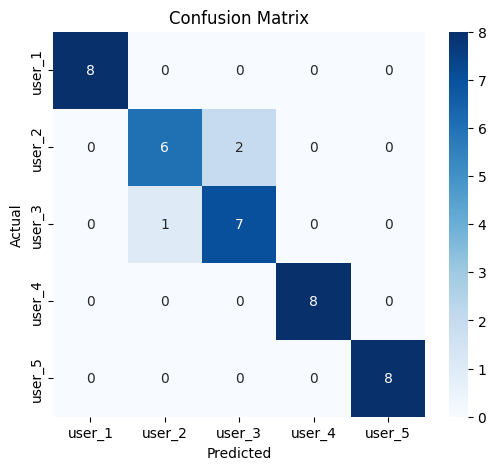

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

      user_1       1.00      1.00      1.00         8
      user_2       0.86      0.75      0.80         8
      user_3       0.78      0.88      0.82         8
      user_4       1.00      1.00      1.00         8
      user_5       1.00      1.00      1.00         8

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40



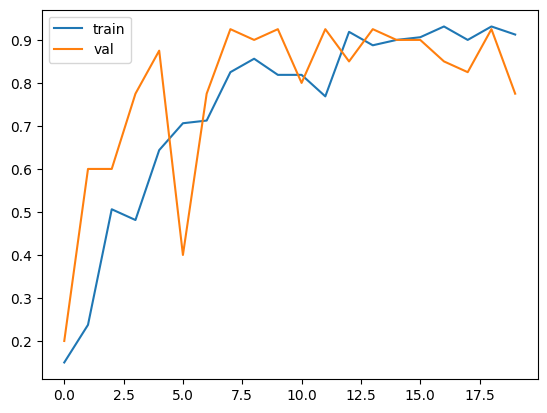

In [16]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

In [17]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_palm(img_path):
    img = image.load_img(img_path, target_size=(128,128))
    img = image.img_to_array(img)/255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    confidence = np.max(pred)
    class_index = np.argmax(pred)

    if confidence < 0.7:
        return "Unknown"
    else:
        return list(train_data.class_indices.keys())[class_index]

In [19]:
import cv2
import numpy as np
from collections import deque

cap = cv2.VideoCapture(1)   #for USB camera connected

pred_queue = deque(maxlen=5)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.flip(frame, 1)

    h, w, _ = frame.shape
    crop = frame[h//4:3*h//4, w//4:3*w//4]

    img = cv2.resize(crop, (128,128))
    img = cv2.GaussianBlur(img, (5,5), 0)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    confidence = np.max(pred)
    class_index = np.argmax(pred)

    pred_queue.append(class_index)

    if len(pred_queue) == 5:
        class_index = max(set(pred_queue), key=pred_queue.count)

    if confidence < 0.85:
        label = "Unknown"
    else:
        label = list(train_data.class_indices.keys())[class_index]

    label = f"{label} ({confidence:.2f})"

    cv2.putText(frame, label, (20,50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    cv2.rectangle(frame, (w//4, h//4), (3*w//4, 3*h//4), (255,0,0), 2)

    cv2.imshow("Palm Recognition", frame)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()